# **IMDB Movie Dataset Analysist**


# Project Objectives

This is formatted as code
The main objective is to clean,
analyze, visualize, and extract meaningful insights from IMDB movie data using Python and MySQL.




# Import Required Libraries

In [57]:
!pip install mysql-connector-python

In [58]:
import pandas as pd

In [59]:
import mysql.connector

In [60]:
!apt-get update
!apt-get install -y mysql-server

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mysql-server is already the newest version (8.0.46-0ubuntu0.22.04.3).
0 upgraded, 0 newly inst

In [61]:
!service mysql start
!service mysql status

 * Starting MySQL database server mysqld
   ...done.
 * /usr/bin/mysqladmin  Ver 8.0.46-0ubuntu0.22.04.3 for Linux on x86_64 ((Ubuntu))
Copyright (c) 2000, 2026, Oracle and/or its affiliates.

Oracle is a registered trademark of Oracle Corporation and/or its
affiliates. Other names may be trademarks of their respective
owners.

Server version		8.0.46-0ubuntu0.22.04.3
Protocol version	10
Connection		Localhost via UNIX socket
UNIX socket		/var/run/mysqld/mysqld.sock
Uptime:			1 hour 14 min 11 sec

Threads: 3  Questions: 92  Slow queries: 0  Opens: 218  Flush tables: 3  Open tables: 137  Queries per second avg: 0.020


In [62]:
!
# Use the debian-sys-maint user (whose credentials are in /etc/mysql/debian.cnf)
# to log in and set the root user's password. This is a more robust approach
# when direct `ALTER USER` commands for 'root' fail in Colab environments.
!mysql --defaults-extra-file=/etc/mysql/debian.cnf -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'root';"

# Then, flush privileges for the new password to take effect.
!mysql --defaults-extra-file=/etc/mysql/debian.cnf -e "FLUSH PRIVILEGES;"

# Verify login with the new password for the root user.
!mysql -u root -proot -e "SELECT 'MySQL login successful';"

print("MySQL user 'root'@'localhost' password set and privileges flushed using debian-sys-maint.")

mysql: [Warning] Using a password on the command line interface can be insecure.
+------------------------+
| MySQL login successful |
+------------------------+
| MySQL login successful |
+------------------------+
MySQL user 'root'@'localhost' password set and privileges flushed using debian-sys-maint.


Connecting mysql

In [63]:
import mysql.connector

conn = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="root",
    database="Movie",
    auth_plugin="mysql_native_password"
)

print("Connected successfully!")

Connected successfully!


# Load the Dataset

In [64]:
from google.colab import files

uploaded = files.upload()

Saving imdb_movies.csv to imdb_movies (2).csv


# Data Understanding and Exploration

In [65]:
cursor = conn.cursor()

create_table_query = """
CREATE TABLE IF NOT EXISTS imdb_movies (
    id INT AUTO_INCREMENT PRIMARY KEY,
    movie_id INT,
    title VARCHAR(255),
    genre VARCHAR(255),
    rating FLOAT,
    budget_million FLOAT,
    gross_million FLOAT,
    director VARCHAR(255),
    lead_actor VARCHAR(255),
    release_year INT
);
"""

try:
    cursor.execute(create_table_query)
    conn.commit()
    print("Table 'imdb_movies' created successfully or already exists.")
except mysql.connector.Error as err:
    print(f"Error creating table: {err}")
finally:
    cursor.close()

Table 'imdb_movies' created successfully or already exists.


# Data Cleaning and Preprocessing

In [66]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('/content/imdb_movies (1).csv')

# Make a copy of the original dataset
df_cleaned_for_sql = df.copy()

# --------------------------------------------------
# 1. MISSING movie_id
# --------------------------------------------------

# Convert movie_id to numeric
df_cleaned_for_sql["movie_id"] = pd.to_numeric(
    df_cleaned_for_sql["movie_id"],
    errors="coerce"
)

# Generate IDs for missing movie_id values
missing_id = df_cleaned_for_sql["movie_id"].isna()

if missing_id.any():
    existing_ids = df_cleaned_for_sql["movie_id"].dropna()

    if len(existing_ids) > 0:
        next_id = int(existing_ids.max()) + 1
    else:
        next_id = 1

    df_cleaned_for_sql.loc[missing_id, "movie_id"] = range(
        next_id,
        next_id + missing_id.sum()
    )

df_cleaned_for_sql["movie_id"] = df_cleaned_for_sql["movie_id"].astype(int)


# --------------------------------------------------
# 2. DUPLICATE MOVIES
# Rule: title + release_year
# Keep highest rating.
# If rating equal, keep highest gross.
# --------------------------------------------------

df_cleaned_for_sql = df_cleaned_for_sql.sort_values(
    by=["title", "release_year", "rating", "gross_million"],
    ascending=[True, True, False, False],
    na_position="last"
)

df_cleaned_for_sql = df_cleaned_for_sql.drop_duplicates(
    subset=["title", "release_year"],
    keep="first"
)


# --------------------------------------------------
# 3. MISSING RATING
# Replace with genre-wise average rating
# --------------------------------------------------

genre_average = df_cleaned_for_sql.groupby(
    "genre"
)["rating"].transform("mean")

df_cleaned_for_sql["rating"] = (
    df_cleaned_for_sql["rating"].fillna(genre_average)
)


# --------------------------------------------------
# Validate rating between 0 and 10
# --------------------------------------------------

invalid_rating = (
    (df_cleaned_for_sql["rating"] < 0) |
    (df_cleaned_for_sql["rating"] > 10)
)

print("Invalid ratings:", invalid_rating.sum())


# --------------------------------------------------
# 4. MISSING DIRECTOR / LEAD ACTOR
# Replace with Unknown
# --------------------------------------------------

df_cleaned_for_sql["director"] = (
    df_cleaned_for_sql["director"].fillna("Unknown")
)

df_cleaned_for_sql["lead_actor"] = (
    df_cleaned_for_sql["lead_actor"].fillna("Unknown")
)


# --------------------------------------------------
# FINAL CHECK
# --------------------------------------------------

print("Final rows:", len(df_cleaned_for_sql))
print("\nMissing values:")
print(df_cleaned_for_sql.isnull().sum())

print("\nDuplicate title + release_year:",
      df_cleaned_for_sql.duplicated(
          subset=["title", "release_year"]
      ).sum())

print("\nRating range:",
      df_cleaned_for_sql["rating"].min(),
      "to",
      df_cleaned_for_sql["rating"].max())

df_cleaned_for_sql.head()

Invalid ratings: 0
Final rows: 5473

Missing values:
movie_id            0
title               0
genre               0
rating              0
budget_million    928
gross_million     913
director            0
lead_actor          0
release_year      610
dtype: int64

Duplicate title + release_year: 0

Rating range: 3.5 to 9.5


,movie_id,title,genre,rating,budget_million,gross_million,director,lead_actor,release_year
0,1,Movie 1,Thriller,4.2,100.0,NaN,Cameron,Unknown,2017.0
9,10,Movie 10,Sci-Fi,5.0,NaN,20.0,Spielberg,Actor B,2019.0
1000,1001,Movie 1001,Comedy,6.4,NaN,20.0,Rajamouli,Actor D,2021.0
1001,1002,Movie 1002,Comedy,7.6,60.0,150.0,Cameron,Unknown,NaN
1002,5559,Movie 1003,Sci-Fi,9.1,150.0,150.0,Spielberg,Actor C,2019.0


In [67]:
cursor = conn.cursor()

# Prepare the INSERT statement dynamically based on DataFrame columns
columns = ', '.join([f'`{col}`' for col in df_cleaned_for_sql.columns])
placeholders = ', '.join(['%s'] * len(df_cleaned_for_sql.columns))
insert_query = f"INSERT INTO imdb_movies ({columns}) VALUES ({placeholders})"

# Prepare the data for insertion
data_to_insert = [tuple(row) for row in df_cleaned_for_sql.values]

try:
    # Execute the insert query for all rows at once using executemany
    cursor.executemany(insert_query, data_to_insert)
    conn.commit()
    print(f"Successfully inserted {cursor.rowcount} rows into 'imdb_movies'.")
except mysql.connector.Error as err:
    print(f"Error inserting data: {err}")
finally:
    cursor.close()
    # You might want to keep the connection open for subsequent SQL analytics,
    # but for now, we'll close it if we're done with this step.
    # conn.close() # Do not close if you intend to run more queries.

Successfully inserted 5473 rows into 'imdb_movies'.


# SQL Analytics

In [68]:
sql_query_top_grossing = """
WITH RankedMovies AS (
    SELECT
        title,
        release_year,
        gross_million,
        ROW_NUMBER() OVER (PARTITION BY release_year ORDER BY gross_million DESC) as rn
    FROM
        imdb_movies
    WHERE
        release_year IS NOT NULL AND gross_million IS NOT NULL
)
SELECT
    title,
    release_year,
    gross_million
FROM
    RankedMovies
WHERE
    rn <= 10
ORDER BY
    release_year DESC, gross_million DESC;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_top_grossing)
    top_grossing_movies_by_year = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    top_grossing_df = pd.DataFrame(top_grossing_movies_by_year, columns=['title', 'release_year', 'gross_million'])
    print("Top 10 highest-grossing movies by year (from MySQL):")
    print(top_grossing_df.head(20)) # Print first 20 to show a couple of years
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 10 highest-grossing movies by year (from MySQL):
         title  release_year  gross_million
0   Movie 1492          2022          600.0
1   Movie 1420          2022          600.0
2   Movie 1419          2022          600.0
3   Movie 1408          2022          600.0
4   Movie 1299          2022          600.0
5   Movie 1239          2022          600.0
6   Movie 1231          2022          600.0
7   Movie 1170          2022          600.0
8   Movie 1085          2022          600.0
9   Movie 1040          2022          600.0
10  Movie 2604          2021          600.0
11   Movie 270          2021          600.0
12  Movie 2704          2021          600.0
13  Movie 2720          2021          600.0
14  Movie 2814          2021          600.0
15  Movie 2871          2021          600.0
16  Movie 2890          2021          600.0
17   Movie 295          2021          600.0
18  Movie 2964          2021          600.0
19  Movie 2816          2021          600.0


In [69]:
sql_query_genre_avg_rating = """
SELECT
    genre,
    AVG(rating) AS average_rating
FROM
    imdb_movies
WHERE
    genre IS NOT NULL AND rating IS NOT NULL
GROUP BY
    genre
ORDER BY
    average_rating DESC;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_genre_avg_rating)
    genre_avg_ratings = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    genre_avg_ratings_df = pd.DataFrame(genre_avg_ratings, columns=['genre', 'average_rating'])
    print("Average rating distribution across genres (from MySQL):")
    print(genre_avg_ratings_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Average rating distribution across genres (from MySQL):
      genre  average_rating
0    Sci-Fi        6.640359
1    Action        6.582437
2  Thriller        6.520365
3   Fantasy        6.506959
4   Romance        6.478184
5    Comedy        6.472558
6     Drama        6.465422
7    Horror        6.419614


In [70]:
sql_query_top_directors = """
SELECT
    director,
    AVG(rating) AS average_rating
FROM
    imdb_movies
WHERE
    director IS NOT NULL AND director != 'Unknown' AND rating IS NOT NULL
GROUP BY
    director
ORDER BY
    average_rating DESC
LIMIT 5;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_top_directors)
    top_directors_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    top_directors_df = pd.DataFrame(top_directors_data, columns=['director', 'average_rating'])
    print("Top 5 directors by average movie rating (from MySQL):")
    print(top_directors_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 5 directors by average movie rating (from MySQL):
    director  average_rating
0   Scorsese        6.589818
1  Spielberg        6.580710
2  Tarantino        6.519267
3      Nolan        6.454953
4    Cameron        6.428989


In [71]:
sql_query_budget_gross = """
SELECT
    budget_million,
    gross_million
FROM
    imdb_movies
WHERE
    budget_million IS NOT NULL AND gross_million IS NOT NULL;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_budget_gross)
    budget_gross_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    budget_gross_df = pd.DataFrame(budget_gross_data, columns=['budget_million', 'gross_million'])
    print("Sample of Budget vs Gross data (from MySQL):")
    print(budget_gross_df.head())

    # Calculate correlation
    correlation = budget_gross_df['budget_million'].corr(budget_gross_df['gross_million'])
    print(f"\nCorrelation between Budget and Gross: {correlation:.2f}")
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Sample of Budget vs Gross data (from MySQL):
   budget_million  gross_million
0            60.0          150.0
1           150.0          150.0
2            10.0           80.0
3            30.0          300.0
4            10.0           20.0

Correlation between Budget and Gross: 0.01


In [72]:
sql_query_profitable_genre = """
SELECT
    genre,
    AVG(gross_million - budget_million) AS average_profit_million
FROM
    imdb_movies
WHERE
    gross_million IS NOT NULL AND budget_million IS NOT NULL
GROUP BY
    genre
ORDER BY
    average_profit_million DESC
LIMIT 5;
"""

try:
    cursor = conn.cursor()
    cursor.execute(sql_query_profitable_genre)
    profitable_genre_data = cursor.fetchall()
    # Convert to DataFrame for easier viewing/plotting
    profitable_genre_df = pd.DataFrame(profitable_genre_data, columns=['genre', 'average_profit_million'])
    print("Top 5 most profitable genres (from MySQL):")
    print(profitable_genre_df)
except mysql.connector.Error as err:
    print(f"Error executing query: {err}")
finally:
    if 'cursor' in locals() and cursor is not None:
        cursor.close()

Top 5 most profitable genres (from MySQL):
      genre  average_profit_million
0     Drama              166.215054
1  Thriller              165.195876
2   Fantasy              164.158004
3    Action              163.801296
4    Sci-Fi              160.912863


# Matplotlib Dashboards

/tmp/ipykernel_614/78240088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gross_million', y='title', data=year_df, palette='viridis')
/tmp/ipykernel_614/78240088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gross_million', y='title', data=year_df, palette='viridis')
/tmp/ipykernel_614/78240088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gross_million', y='title', data=year_df, palette='viridis')
/tmp/ipykernel_614/78240088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

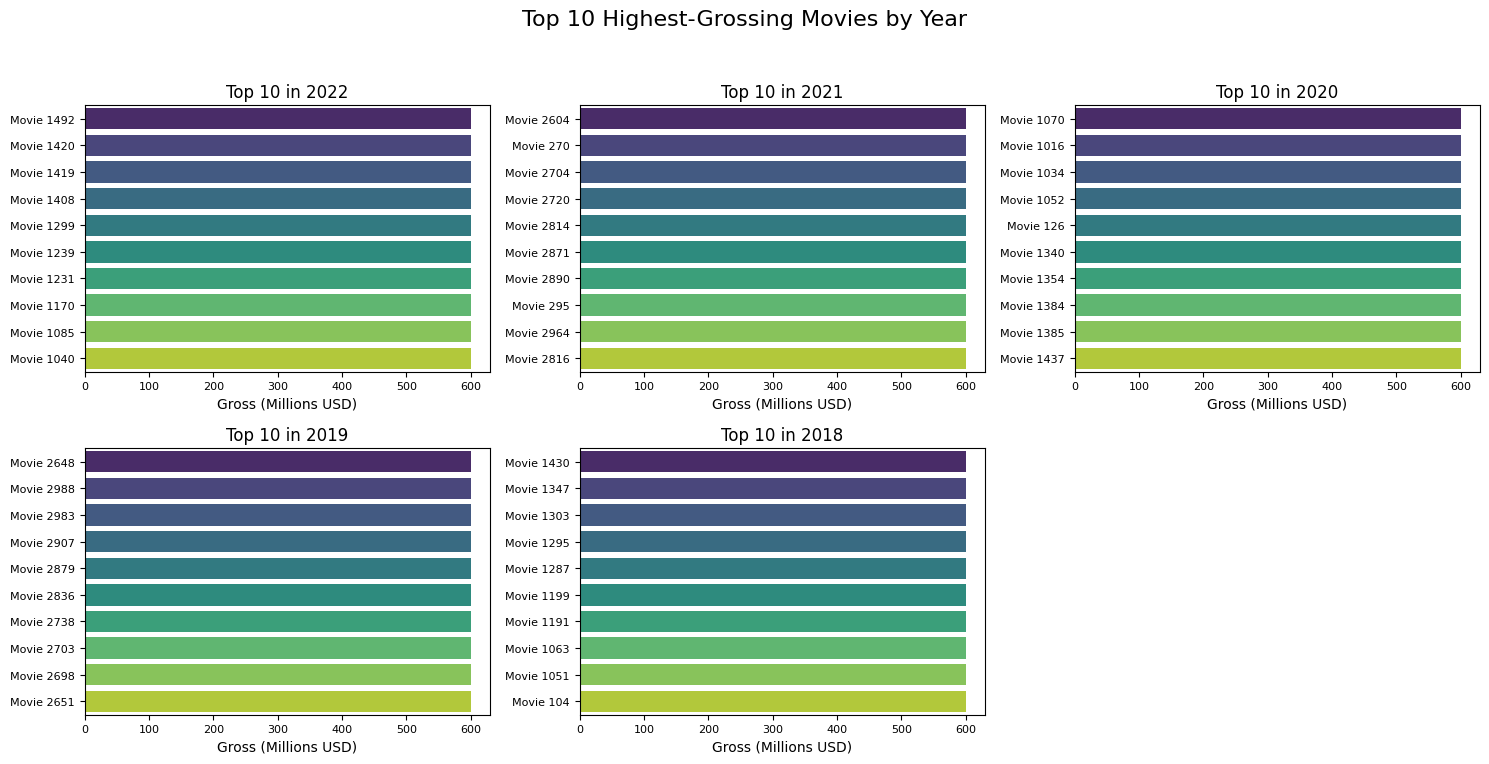

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame to ensure correct plotting if not already sorted
top_grossing_df_sorted = top_grossing_df.sort_values(by=['release_year', 'gross_million'], ascending=[False, False])

# Get unique years for iteration
years = top_grossing_df_sorted['release_year'].unique()

plt.figure(figsize=(15, 8))
plt.suptitle('Top 10 Highest-Grossing Movies by Year', fontsize=16)

for i, year in enumerate(years[:5]): # Plot for the first 5 years to keep it concise, can adjust
    year_df = top_grossing_df_sorted[top_grossing_df_sorted['release_year'] == year].head(10)

    if not year_df.empty:
        plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
        sns.barplot(x='gross_million', y='title', data=year_df, palette='viridis')
        plt.title(f'Top 10 in {int(year)}', fontsize=12)
        plt.xlabel('Gross (Millions USD)', fontsize=10)
        plt.ylabel('') # Clear y-label for better readability on subplots
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_614/3970157338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_rating', y='genre', data=genre_avg_ratings_df, palette='coolwarm')


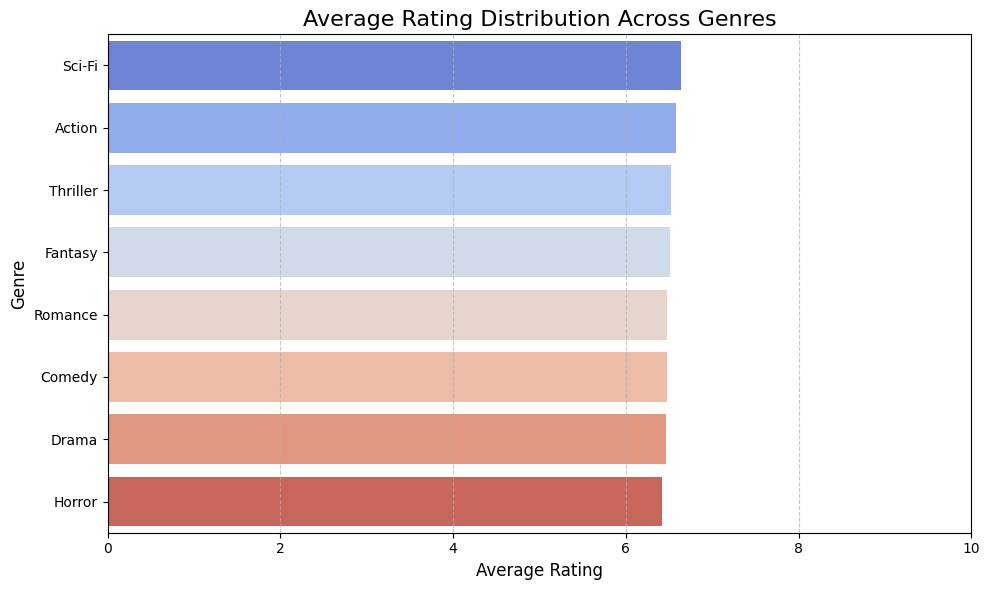

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_rating', y='genre', data=genre_avg_ratings_df, palette='coolwarm')
plt.title('Average Rating Distribution Across Genres', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(0, 10) # Ratings are typically 0-10
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_614/4134651284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_rating', y='director', data=top_directors_df, palette='magma')


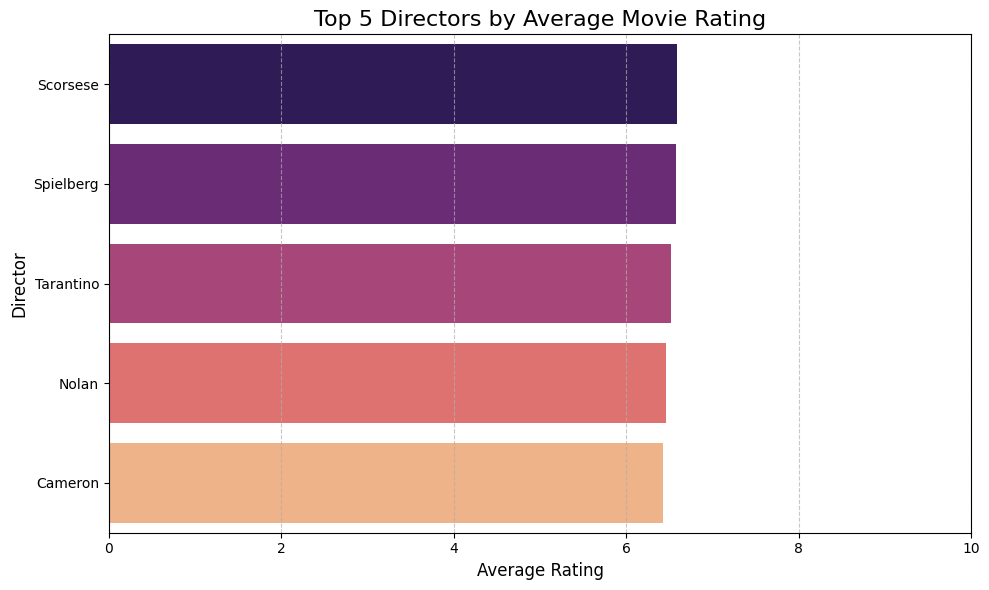

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_rating', y='director', data=top_directors_df, palette='magma')
plt.title('Top 5 Directors by Average Movie Rating', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.xlim(0, 10) # Ratings are typically 0-10
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

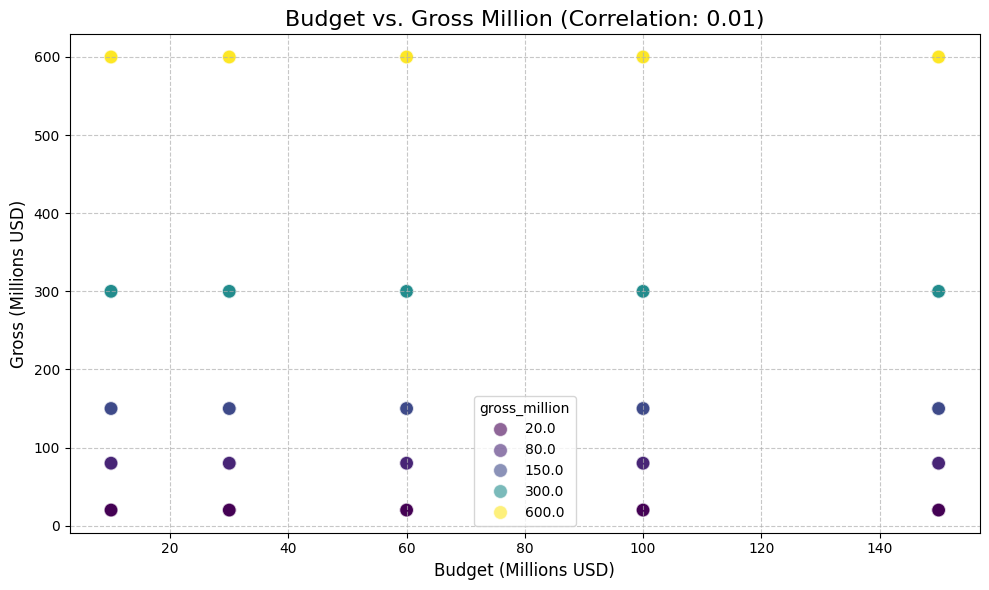

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget_million', y='gross_million', data=budget_gross_df, alpha=0.6, s=100, hue='gross_million', palette='viridis')
plt.title('Budget vs. Gross Million (Correlation: {:.2f})'.format(correlation), fontsize=16)
plt.xlabel('Budget (Millions USD)', fontsize=12)
plt.ylabel('Gross (Millions USD)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_614/3801212803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_profit_million', y='genre', data=profitable_genre_df, palette='rocket')


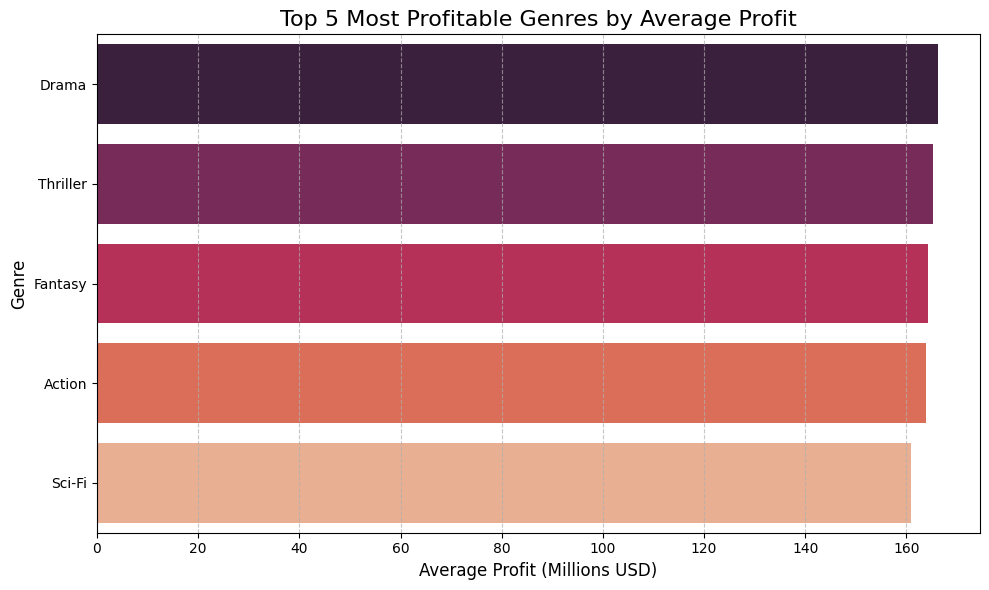

In [77]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_profit_million', y='genre', data=profitable_genre_df, palette='rocket')
plt.title('Top 5 Most Profitable Genres by Average Profit', fontsize=16)
plt.xlabel('Average Profit (Millions USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Conclusion

The IMDB Movie Dataset Analysis successfully cleaned and analyzed movie data using Python, MySQL, Pandas, NumPy, and Matplotlib. The analysis helped identify trends in movie ratings, genres, budgets, revenue, and other factors. SQL analytics and visualizations provided meaningful insights that can support better decision-making in the movie industry.